In [1]:
import numpy as np
import scanpy as sc
import pandas as pd
import os
from matplotlib import pyplot as plt
from umap import UMAP
import seaborn as sns
import sys; sys.path += ['./../../']
from CardamomOT import NetworkModel as CardamomNetworkModel
from CardamomOT import train_classifier, predict_cell_types
from harissa import NetworkModel as HarissaNetworkModel

In [2]:
def run_inference(rna_data, prot_data, deg_rates, random_state=42, min_dist=0.7, n_neighbors=15):
    rna_traj = rna_data[1:,1:].copy()
    # ---- CardamomOT fit ----
    time = rna_data[1:, 0]
    valid_mask = time > 0
    x = rna_data[1:, 1:].copy()
    x[:, 0] = time
    G = x.shape[1]
    model = CardamomNetworkModel(G - 1)
    model.d = deg_rates
    print(x.shape)
    model.fit_mixture(x, min_components=2, max_components=2, max_iter_kinetics=0)
    model.fit_network(x, intensity_prior=100)
    model.adapt_to_unitary()

    inferred_prot = model.prot
    reference_prot = prot_data[valid_mask]
    inferred_prot = inferred_prot[valid_mask]
    reference_prot_scaled = reference_prot / np.max(reference_prot, axis=0)
    inferred_prot_scaled = inferred_prot / np.max(inferred_prot, axis=0)
    umap_model = UMAP(n_components=2, random_state=random_state, min_dist=min_dist, n_neighbors=n_neighbors)
    reference_umap = umap_model.fit_transform(reference_prot_scaled)
    inferred_umap = umap_model.transform(inferred_prot_scaled)

    return reference_umap, inferred_umap, time[valid_mask]

# FN4

In [10]:
np.random.seed(0)

# Number of cells
C = 1000
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 4

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 1
model_harissa.d[1] = 0.2
model_harissa.d /= 5

model_harissa.basal[1:] = -5
model_harissa.inter[0,1] = 10
model_harissa.inter[1,2] = 10
model_harissa.inter[1,3] = 10
model_harissa.inter[3,4] = 10
model_harissa.inter[4,1] = -10
model_harissa.inter[2,2] = 10
model_harissa.inter[3,3] = 10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj_FN4 = np.ones((C, G+1), dtype='float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj_FN4[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj_FN4 = data[1:,1:].copy()

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]


In [11]:
reference_umap_FN4, inferred_umap_FN4, time = run_inference(data, prot_traj_FN4, model_harissa.d.copy())

(1000, 5)
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Gene 1-1 calibrated... [0.011 2.139] 0.021111393837854497
Gene 2-2 calibrated... [0.01  2.028] 0.019671948790519835
Gene 3-3 calibrated... [0.011 2.38 ] 0.022182070511679187
Gene 4-4 calibrated... [0.011 1.88 ] 0.021663301792092676
Mean proba =  0.9784498944736979 1.0
[fit_network] Cell counts per sample/timepoint and genes:
 [[100 100 100 100 100 100 100 100 100 100]] 5
[fit_network] Number of simulated cells per sample: [100]
[fit_network] Number of total cells per sample: [100]
1 0 | Errors (before, after): 0.69194, 0.24628 | alpha mean: 0.0100
number of non reached cells 329
2 0 | Errors (before, after): 0.21896, 0.21077 | alpha mean: 0.0352
number of non reached cells 322
3 0 | Errors (before, after): 0.19818, 0.19311 | alpha mean: 0.0488
number of non reached cells 337
4 0 | Errors (before, after): 0.18283, 0.17905 | alpha mean: 0.0553
number of non reached cells 331
5 0 | Errors (before, after)

2026-03-17 16:22:42,138 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.354647e-03 max scale = 1.321e+00
2026-03-17 16:22:42,141 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 5.714750e-03 max scale = 1.306e+00
2026-03-17 16:22:42,144 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.208555e-03 max scale = 1.306e+00
2026-03-17 16:22:42,145 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 6.088066e-03 max scale = 1.321e+00
2026-03-17 16:22:42,150 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 5.288901e-03 max scale = 1.321e+00
2026-03-17 16:22:42,152 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 4.672713e-03 max scale = 1.306e+00
2026-03-17 16:22:42,155 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 4.525486e-03 max scale = 1.306e+00
2026-03-17 16:22:42,161 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 6.117700e-03 max scale = 1.306e+00


[adapt_unitary]  Static network unitary [array([[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 6.92 ,  5.935, -0.   ,  0.001, -7.78 ],
       [-0.   ,  9.217,  4.743,  0.115,  0.016],
       [ 0.   ,  6.908,  0.001,  5.365,  0.47 ],
       [ 0.   ,  0.   , -0.001,  6.693,  3.939]])] [array([ 0.   , -5.36 , -6.051, -4.9  , -4.413])]


# CN5

In [5]:
np.random.seed(0)

# Number of cells
C = 1000
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 5

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 0.5
model_harissa.d[1] = 0.1

model_harissa.basal[1:] = [-5, 4, 4, -5, -5]
model_harissa.inter[0, 1] = 10
model_harissa.inter[1, 2] = -10
model_harissa.inter[2, 3] = -10
model_harissa.inter[3, 4] = 10
model_harissa.inter[4, 5] = 10
model_harissa.inter[5, 1] = -10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj_CN5 = np.ones((C, G+1), dtype='float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj_CN5[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj_CN5 = data[1:,1:].copy()

reference_umap_CN5, inferred_umap_CN5, time = run_inference(data, prot_traj_CN5, model_harissa.d.copy())

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]
(1000, 6)
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Gene 1-1 calibrated... [0.01  1.945] 0.019497825030839896
Gene 2-2 calibrated... [0.153 2.643] 0.027811985883679828
Gene 3-3 calibrated... [0.318 2.965] 0.029405040774904752
Gene 4-4 calibrated... [0.116 2.176] 0.023452308143752293
Gene 5-5 calibrated... [0.008 1.316] 0.015531448409116225
Mean proba =  0.9328146119634686 1.0
[fit_network] Cell counts per sample/timepoint and genes:
 [[100 100 100 100 100 100 100 100 100 100]] 6
[fit_network] Number of simulated cells per sample: [100]
[fit_network] Number of total cells per sample: [100]
1 0 | Errors (before, after): 0.68611, 0.37747 | alpha mean: 0.0100
number of non reached cells 340
2 0 | Errors (before, after): 0.37343, 0.35372 | alpha mean: 0.2136
number of non reached cells 331
3 0 | Errors (before, after): 0.32725, 0.33057 | alpha mean: 0.2304
number of non reached cells 318
4 0 | Er

2026-03-17 16:21:35,037 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.284078e-02 max scale = 1.321e+00
2026-03-17 16:21:35,040 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 9.033710e-03 max scale = 1.321e+00
2026-03-17 16:21:35,047 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 2.992600e-02 max scale = 1.306e+00
2026-03-17 16:21:35,052 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 3.118190e-02 max scale = 1.321e+00
2026-03-17 16:21:35,057 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 2.627168e-02 max scale = 1.321e+00
2026-03-17 16:21:35,069 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 2.800444e-02 max scale = 1.306e+00
2026-03-17 16:21:35,621 | CardamomOT.inference.degradations | INFO | [Epoch 50/500] loss = 3.683666e-03 max scale = 1.650e+00
2026-03-17 16:21:35,621 | CardamomOT.inference.degradations | INFO | [Epoch 50/500] loss = 1.090966e-02 max scale = 1.519e+0

[adapt_unitary]  Static network unitary [array([[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 6.458,  9.228,  5.091, -0.111, -2.222, -4.036],
       [ 0.   , -3.529,  3.778,  1.258,  0.   ,  1.291],
       [-0.879, -0.151, -4.679,  4.995,  0.   , -1.768],
       [ 0.334,  1.918, -0.001,  3.833,  4.166, -0.   ],
       [ 0.   , -0.   ,  0.   ,  0.   ,  4.731,  3.597]])] [array([ 0.   , -8.396, -1.672,  1.341, -5.555, -3.872])]


# BN8

In [6]:
np.random.seed(0)

# Number of cells
C = 1000

# Time points
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96] 
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 8

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 0.25
model_harissa.d[1] = 0.05

model_harissa.basal[1:] = [-4, -4, -4, -4, -4, -4, -4, -4]
model_harissa.inter[0, 1] = 10
model_harissa.inter[1, 2] = 10
model_harissa.inter[1, 3] = 10
model_harissa.inter[3, 2] = -10
model_harissa.inter[2, 3] = -10
model_harissa.inter[2, 2] = 5
model_harissa.inter[3, 3] = 5
model_harissa.inter[2, 4] = 10
model_harissa.inter[3, 5] = 10
model_harissa.inter[2, 5] = -10
model_harissa.inter[3, 4] = -10
model_harissa.inter[4, 7] = -10
model_harissa.inter[5, 6] = -10
model_harissa.inter[4, 6] = 10
model_harissa.inter[5, 7] = 10
model_harissa.inter[7, 8] = 10
model_harissa.inter[6, 8] = -10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj_BN8 = np.ones((C, G+1), dtype='float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj_BN8[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj_BN8 = data[1:,1:].copy()

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]


In [7]:
reference_umap_BN8, inferred_umap_BN8, time = run_inference(data, prot_traj_BN8, model_harissa.d.copy())

(1000, 9)
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Calibrating gene 6
Calibrating gene 7
Calibrating gene 8
Gene 1-1 calibrated... [0.032 1.998] 0.018844425083683173
Gene 2-2 calibrated... [0.009 1.067] 0.013063583793611003
Gene 3-3 calibrated... [0.009 1.15 ] 0.01500749677432194
Gene 4-4 calibrated... [0.006 0.764] 0.011023949852052756
Gene 5-5 calibrated... [0.008 1.135] 0.016587575460910546
Gene 6-6 calibrated... [0.007 0.788] 0.013979254121655679
Gene 7-7 calibrated... [0.006 0.75 ] 0.012780016524745969
Gene 8-8 calibrated... [0.007 0.667] 0.013115834408433568
Mean proba =  0.9713816286645013 1.0
[fit_network] Cell counts per sample/timepoint and genes:
 [[100 100 100 100 100 100 100 100 100 100]] 9
[fit_network] Number of simulated cells per sample: [100]
[fit_network] Number of total cells per sample: [100]
1 0 | Errors (before, after): 0.69348, 0.35913 | alpha mean: 0.0100
number of non reached cells 324
2 0 | Errors (before,

2026-03-17 16:21:51,215 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.168770e-02 max scale = 1.321e+00
2026-03-17 16:21:51,217 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 3.237211e-03 max scale = 1.321e+00
2026-03-17 16:21:51,217 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.259890e-02 max scale = 1.321e+00
2026-03-17 16:21:51,218 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.380190e-02 max scale = 1.306e+00
2026-03-17 16:21:51,220 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 7.331744e-03 max scale = 1.321e+00
2026-03-17 16:21:51,221 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.253162e-02 max scale = 1.321e+00
2026-03-17 16:21:51,223 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 7.903231e-03 max scale = 1.321e+00
2026-03-17 16:21:51,688 | CardamomOT.inference.degradations | INFO | [Epoch 50/500] loss = 2.968331e-03 max scale = 1.690e+00

[adapt_unitary]  Static network unitary [array([[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
         0.   ],
       [ 4.926,  4.919, -0.   , -0.   , -0.001, -0.001, -0.001, -0.001,
        -0.   ],
       [ 0.   ,  6.995,  3.626, -2.59 ,  0.   , -2.23 , -0.086,  0.   ,
        -0.78 ],
       [ 0.001,  4.342, -0.   ,  5.292, -4.161,  0.   ,  0.001, -0.001,
        -0.   ],
       [ 0.   ,  0.119,  3.901, -2.402,  3.895, -0.645, -0.001, -0.   ,
        -0.001],
       [ 0.001,  0.208, -3.866,  5.425, -0.885,  3.571, -0.   ,  0.001,
         0.   ],
       [ 0.   , -0.001, -0.001, -0.099,  6.295, -0.011,  6.087, -0.001,
        -0.001],
       [ 0.   , -0.001, -1.588, -0.301, -0.   ,  7.01 ,  0.   ,  3.305,
        -0.   ],
       [ 0.   , -0.   , -0.278,  0.   , -0.096,  3.273, -0.001,  0.634,
         7.119]])] [array([ 0.   , -3.742, -3.722, -3.109, -3.039, -3.012, -4.802, -2.912,
       -4.166])]


# FN8

In [8]:
np.random.seed(0)

# Number of cells
C = 1000
# Time points
t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96] # np.linspace(0, 25, 10, dtype='int')
N = int(C /len(t))
k = np.linspace(0, C, len(t) + 1, dtype='int')
print(f't = {t}')
time = np.zeros(C, dtype='int')
for i in range(len(t)): time[k[i]:k[i+1]] = t[i]

# Number of genes
G = 8

# Prepare data
data = np.zeros((C+1,G+2), dtype='int')
data[0][1:] = np.arange(G+1)
data[1:,0] = time # Time points
data[1:,1] = 100 * (time > 0) # Stimulus

# Initialize the model
model_harissa = HarissaNetworkModel(G)
model_harissa.d[0] = 0.4
model_harissa.d[1] = 0.08

model_harissa.basal[1:] = [-5, -5, -5, -5, -5, -5, -5, -5]
model_harissa.inter[0, 1] = 10
model_harissa.inter[1, 2] = 10
model_harissa.inter[2, 3] = 10
model_harissa.inter[3, 4] = 10
model_harissa.inter[3, 5] = 10
model_harissa.inter[3, 6] = 10
model_harissa.inter[4, 1] = -10
model_harissa.inter[5, 1] = -10
model_harissa.inter[6, 1] = -10
model_harissa.inter[4, 4] = 10
model_harissa.inter[5, 5] = 10
model_harissa.inter[6, 6] = 10
model_harissa.inter[4, 8] = -10
model_harissa.inter[4, 7] = -10
model_harissa.inter[6, 7] = 10
model_harissa.inter[7, 6] = 10
model_harissa.inter[8, 8] = 10

inter_true = 1 * (abs(model_harissa.inter) > 0)

prot_traj_FN8 = np.ones((C, G+1), dtype='float32')
for k in range(C):
    sim = model_harissa.simulate(time[k], burnin=5)
    prot_traj_FN8[k,1:] = sim.p[-1]
    data[k+1,2:] = np.random.poisson(sim.m[-1])
rna_traj_FN8 = data[1:,1:].copy()

reference_umap_FN8, inferred_umap_FN8, time = run_inference(data, prot_traj_FN8, model_harissa.d.copy())

t = [0, 6, 12, 24, 36, 48, 60, 72, 84, 96]
(1000, 9)
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Calibrating gene 6
Calibrating gene 7
Calibrating gene 8
Gene 1-1 calibrated... [0.017 1.972] 0.0195675809469111
Gene 2-2 calibrated... [0.009 1.63 ] 0.01886891936160474
Gene 3-3 calibrated... [0.007 1.075] 0.014347874292772983
Gene 4-4 calibrated... [0.007 1.534] 0.014684189598562481
Gene 5-5 calibrated... [0.012 2.703] 0.024539904473071812
Gene 6-6 calibrated... [0.015 2.438] 0.024512190685865846
Gene 7-7 calibrated... [0.007 0.665] 0.01620572556094255
Gene 8-8 calibrated... [0.015 1.526] 0.1131837729449968
Mean proba =  0.974371294029388 1.0
[fit_network] Cell counts per sample/timepoint and genes:
 [[100 100 100 100 100 100 100 100 100 100]] 9
[fit_network] Number of simulated cells per sample: [100]
[fit_network] Number of total cells per sample: [100]
1 0 | Errors (before, after): 0.69536, 0.24259 | alpha mean: 0.0100
number of non re

2026-03-17 16:22:06,212 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 4.677709e-03 max scale = 1.321e+00
2026-03-17 16:22:06,216 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.674394e-03 max scale = 1.321e+00
2026-03-17 16:22:06,221 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.777780e-02 max scale = 1.321e+00
2026-03-17 16:22:06,225 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 2.202250e-02 max scale = 1.321e+00
2026-03-17 16:22:06,226 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.398796e-02 max scale = 1.321e+00
2026-03-17 16:22:06,227 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.365812e-02 max scale = 1.316e+00
2026-03-17 16:22:06,232 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 8.588569e-03 max scale = 1.321e+00
2026-03-17 16:22:06,234 | CardamomOT.inference.degradations | INFO | [Epoch 1/500] loss = 1.677588e-02 max scale = 1.321e+00


[adapt_unitary]  Static network unitary [array([[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
         0.   ],
       [ 3.767,  4.771,  0.036, -2.598, -3.811,  0.   ,  0.001,  0.   ,
         0.   ],
       [ 0.   ,  7.54 ,  4.475, -0.453, -0.   , -0.   , -0.137,  0.   ,
        -0.   ],
       [-0.   , -0.   ,  5.679,  3.513, -0.   , -0.   , -0.   , -0.   ,
         0.   ],
       [ 0.   , -0.001, -0.068,  3.968,  5.534,  0.692,  0.34 ,  0.   ,
        -0.   ],
       [ 0.   , -0.   , -0.   ,  4.553,  0.379,  7.155,  0.01 , -0.   ,
        -0.   ],
       [ 0.   ,  0.   , -0.   ,  4.147,  0.346,  0.003,  5.964,  0.001,
        -0.   ],
       [ 0.   ,  0.   ,  0.01 ,  1.232,  0.   ,  0.001,  0.001,  5.698,
        -0.   ],
       [-0.   ,  0.   ,  0.   ,  0.   ,  0.   , -0.   , -0.   , -0.   ,
         0.   ]])] [array([ 0.   , -3.313, -5.073, -4.525, -3.864, -4.991, -4.111, -3.46 ,
       -6.786])]


/Users/yannmauge/miniconda3/envs/cardamom_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Plot

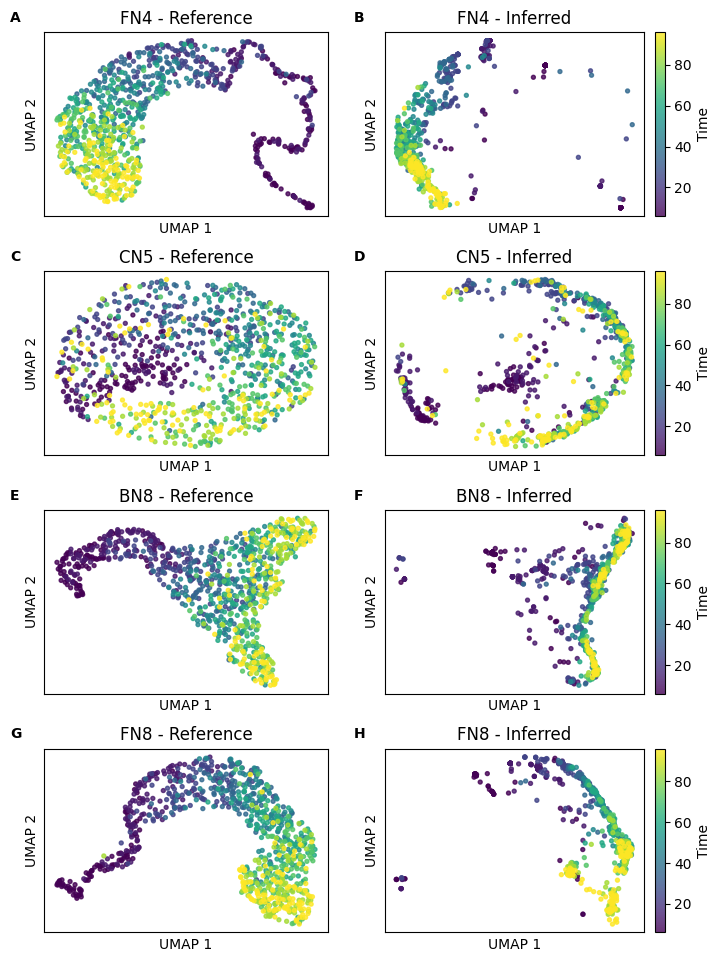

In [9]:
datasets = [
    ("FN4", reference_umap_FN4, inferred_umap_FN4, time),
    ("CN5", reference_umap_CN5, inferred_umap_CN5, time),
    ("BN8", reference_umap_BN8, inferred_umap_BN8, time),
    ("FN8", reference_umap_FN8, inferred_umap_FN8, time),
]
fig, axes = plt.subplots(4, 2, figsize=(8.27, 11.69))

valid_times = [times for _, _, _, times in datasets if len(times) > 0]
vmin = min(np.min(t) for t in valid_times)
vmax = max(np.max(t) for t in valid_times)

def style_axis(ax, title):
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_xticks([])
    ax.set_yticks([])

for row, (dataset_name, reference_umap, inferred_umap, times) in enumerate(datasets):
    ref_plot = reference_umap
    inf_plot = inferred_umap
    times_plot = times

    ax_ref = axes[row, 0]
    ax_ref.scatter(
        ref_plot[:, 0],
        ref_plot[:, 1],
        c=times_plot,
        s=8,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        alpha=0.8,
    )
    style_axis(ax_ref, f"{dataset_name} - Reference")

    ax_inf = axes[row, 1]
    sc_inf = ax_inf.scatter(
        inf_plot[:, 0],
        inf_plot[:, 1],
        c=times_plot,
        s=8,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        alpha=0.8,
    )
    style_axis(ax_inf, f"{dataset_name} - Inferred")
    cbar_inf = fig.colorbar(sc_inf, ax=ax_inf, fraction=0.046, pad=0.04)
    cbar_inf.set_label("Time")

for ax, label in zip(axes.flatten(), "ABCDEFGH"):
    ax.text(
        -0.12,
        1.04,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.subplots_adjust(hspace=0.3, wspace=0.2, right=0.88)
plt.savefig("figureS6.pdf", dpi=600, bbox_inches="tight", pad_inches=0.05)
plt.show()